# Notebook 11 — Calibrazione (digits)

Reliability diagram ed ECE per i tre domini (SVHN, MNIST, USPS), MAP vs.
predittiva di Laplace. Funzioni portate in `code_v2/src/metrics.py`
(`reliability_bins`, `expected_calibration_error`) dal `src/calibration.py` (progetto principale)
del progetto principale, che non ha equivalente in `code_v2` -- nessuna
delle due modificata nella matematica. Ancora nessun adattamento in questo
passo.

## Setup: ricarica checkpoint, fit di Laplace, predittiva

In [1]:
import sys
from pathlib import Path

here = Path().resolve()
for base in [here, *here.parents]:
    if (base / "code_v2" / "src" / "laplace_core.py").is_file():
        sys.path.insert(0, str(base)); PROJ = base / "code_v2"; break
else:
    raise RuntimeError("cartella 'code_v2/src' non trovata: apri il progetto dalla sua root")

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from code_v2.src.digits_data import load_domain
from code_v2.src.digits_model import SmallCNN32
from code_v2.src.bayesian_model import extract, augment, LastLayerLaplace
from code_v2.src.metrics import reliability_bins, expected_calibration_error

MODELS_DIR = PROJ / "models" / "source_svhn"
ckpt = torch.load(MODELS_DIR / "model.pt", map_location="cpu", weights_only=False)
lap_data = np.load(MODELS_DIR / "svhn_laplace.npz")
mean, std = ckpt["source_mean"], ckpt["source_std"]

model = SmallCNN32(n_classes=ckpt["n_classes"], feature_dim=ckpt["feature_dim"])
model.load_state_dict(ckpt["state_dict"])
model.eval()

# Estrazione feature (e, dove c'e', adattamento) sul device migliore disponibile.
# La predittiva MC sceglie il proprio backend da se' (vedi bayesian_model.py).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")
laplace = LastLayerLaplace(theta_map=lap_data["theta_map"], cov=lap_data["cov"],
                           K=int(lap_data["K"]), Dp=int(lap_data["Dp"]))

EVAL_DOMAINS = ["svhn", "mnist", "usps"]
mc_conv = np.load(MODELS_DIR / "mc_convergence.npz")
M_FIXED = int(mc_conv["M_FIXED"])  # selezionato nel Notebook 10, non riassunto qui
FINAL_SEED = 456

probs_map, probs_lap, y_eval = {}, {}, {}
for domain in EVAL_DOMAINS:
    X_t, y_t = load_domain(domain, "test", mean, std)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=256)
    Phi, y_np, logits_map = extract(model, loader, device=DEVICE)
    Phi_aug = augment(Phi)
    from code_v2.src.laplace_core import softmax
    probs_map[domain] = softmax(logits_map)
    rng = np.random.default_rng(FINAL_SEED)
    pred = laplace.predictive_batched(Phi_aug, M=M_FIXED, rng=rng)
    probs_lap[domain] = pred["probs"]
    y_eval[domain] = y_np

print("probabilità MAP e Laplace calcolate per:", EVAL_DOMAINS)

device: cuda


probabilità MAP e Laplace calcolate per: ['svhn', 'mnist', 'usps']


## ECE, MAP vs. Laplace

In [2]:
print(f"{'dominio':>8s} {'n':>6s} {'ECE (MAP)':>12s} {'ECE (Laplace)':>14s}")
print("-" * 44)
ece_results = {}
for domain in EVAL_DOMAINS:
    y_np = y_eval[domain]
    ece_map = expected_calibration_error(probs_map[domain], y_np)
    ece_lap = expected_calibration_error(probs_lap[domain], y_np)
    ece_results[domain] = (ece_map, ece_lap)
    print(f"{domain:>8s} {len(y_np):6d} {ece_map:12.4f} {ece_lap:14.4f}")

 dominio      n    ECE (MAP)  ECE (Laplace)
--------------------------------------------
    svhn  26032       0.0180         0.0152
   mnist  10000       0.2919         0.2712
    usps   2007       0.2878         0.2767


## Reliability diagram

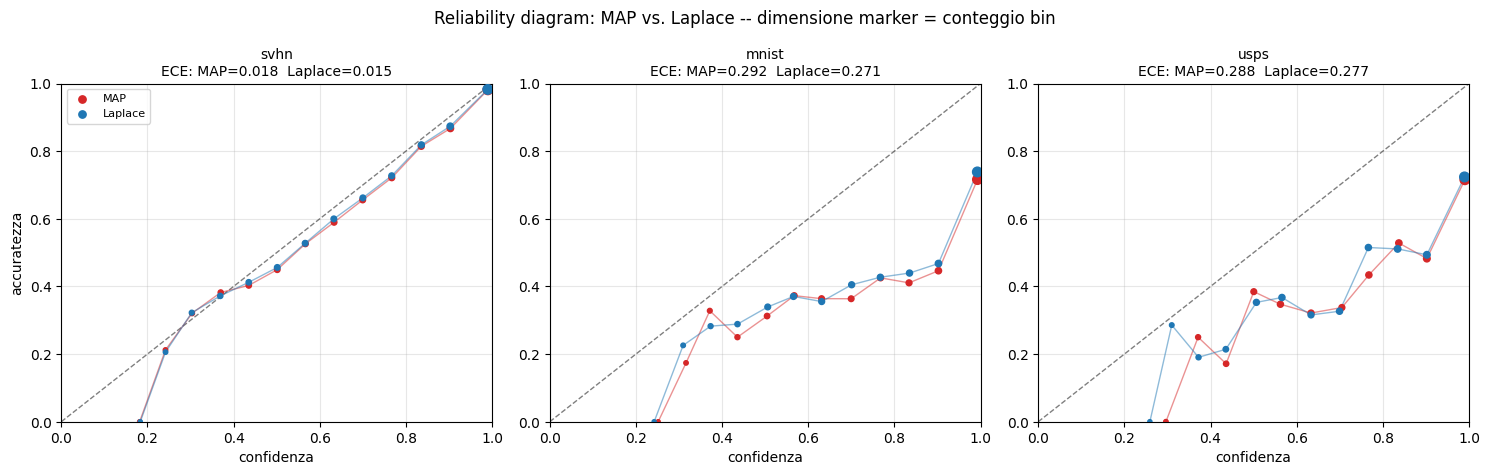

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, domain in zip(axes, EVAL_DOMAINS):
    y_np = y_eval[domain]
    bins_map = reliability_bins(probs_map[domain], y_np, n_bins=15)
    bins_lap = reliability_bins(probs_lap[domain], y_np, n_bins=15)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
    for bins, color, label in [(bins_map, "tab:red", "MAP"), (bins_lap, "tab:blue", "Laplace")]:
        sizes = 8 + 40 * np.sqrt(bins["bin_count"] / max(bins["bin_count"].max(), 1))
        ax.plot(bins["bin_conf"], bins["bin_acc"], "-", color=color, alpha=0.5, linewidth=1, zorder=2)
        ax.scatter(bins["bin_conf"], bins["bin_acc"], s=sizes, color=color, label=label, zorder=3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ece_map, ece_lap = ece_results[domain]
    ax.set_title(f"{domain}\nECE: MAP={ece_map:.3f}  Laplace={ece_lap:.3f}", fontsize=10)
    ax.set_xlabel("confidenza")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("accuratezza")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Reliability diagram: MAP vs. Laplace -- dimensione marker = conteggio bin")
fig.tight_layout()
plt.show()

## Lettura dei risultati

| dominio | n | ECE (MAP) | ECE (Laplace) | variazione |
|---|---:|---:|---:|---:|
| svhn (source, held-out) | 26.032 | 0.0180 | **0.0152** | −16% |
| mnist (target) | 10.000 | 0.2919 | **0.2712** | −7% |
| usps (target) | 2.007 | 0.2878 | **0.2767** | −4% |

**La media bayesiana migliora la calibrazione su tutti e tre i domini, ma di poco — e il
poco è concentrato dove serviva meno.** Sul source l'ECE era già ~0.02 e c'era poco da
recuperare. Sui target è ~0.28-0.29, cioè il modello è confidente intorno al 90% dove è
accurato intorno al 60%: la Laplace lo corregge del 4-7%, lasciando il grosso del divario
intatto.

**Perché non può fare di più.** La posterior è sull'**ultimo layer soltanto**: può
ammorbidire le probabilità dato un vettore di feature, ma non può correggere feature
`g(x)` che sotto shift finiscono già nella regione sbagliata dello spazio. Un'immagine
MNIST mappata dal feature extractor SVHN vicino al prototipo della classe sbagliata resta
lì, e nessuna integrazione sui pesi della testa la sposta. **La overconfidence sotto
covariate shift è in larga parte un problema del feature extractor, non della testa** — e
la last-layer Laplace, per costruzione, non tocca il feature extractor.

È il rovescio esatto del suo pregio: last-layer significa esatta e a basso costo
(l'Hessiana della cross-entropy softmax è esatta per un layer lineare, Notebook 01), ma
anche cieca a tutto ciò che accade prima della testa. Il Notebook 12 mostra il seguito
della storia: dopo l'adattamento l'ECE **peggiora**, perché la loss IM alza la confidenza
per costruzione.